In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

In [11]:
#Create Simple Noisy Data
np.random.seed(42)

X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 100)

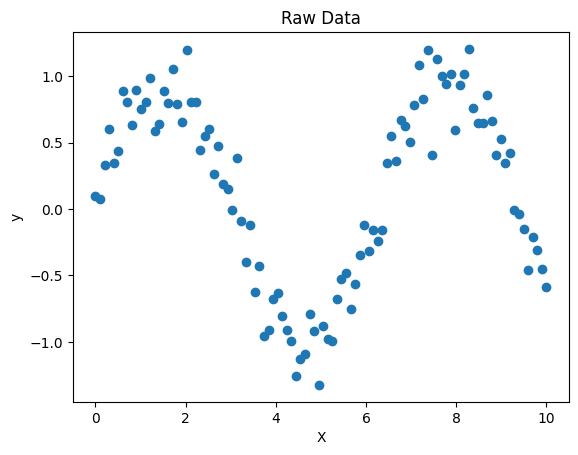

In [12]:
plt.scatter(X, y)
plt.title("Raw Data")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [13]:
model = SVR(kernel='rbf', C=100, epsilon=0.5)
model.fit(X, y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.5
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


Meaning of parameters

kernel='rbf'

allows curved relationships

C=100

penalty if predictions go outside margin

epsilon=0.1

width of the margin (tolerance zone)

In [14]:
y_pred = model.predict(X)

In [15]:
support_vectors = model.support_

These are the points that influence the model.

All other points are mostly ignored.

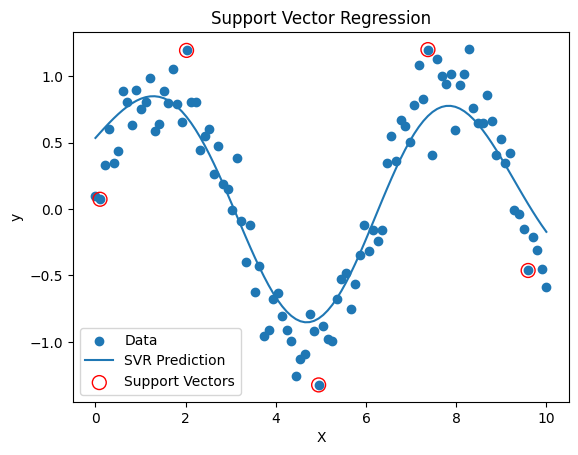

In [16]:
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, label="SVR Prediction")

plt.scatter(X[support_vectors], y[support_vectors],
            facecolors='none', edgecolors='r', s=100,
            label="Support Vectors")

plt.title("Support Vector Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

These circled points are the ones defining the regression function.

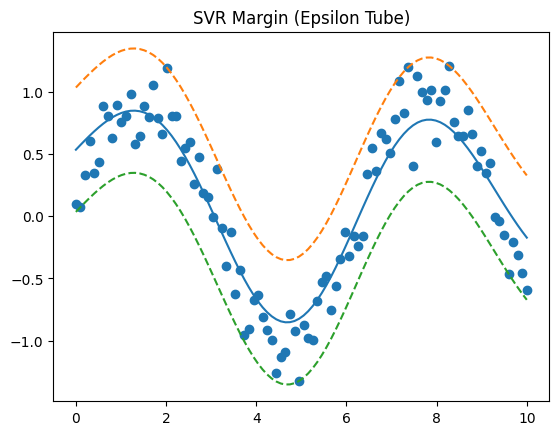

In [17]:
epsilon = model.epsilon

plt.scatter(X, y)
plt.plot(X, y_pred)

plt.plot(X, y_pred + epsilon, linestyle='dashed')
plt.plot(X, y_pred - epsilon, linestyle='dashed')

plt.title("SVR Margin (Epsilon Tube)")
plt.show()

Prediction line
Upper margin
Lower margin

This region is called the epsilon tube.

Points inside it are not penalized.

In [ ]:
epsilon = 0.5 # making margin widerr and if epsilon=0.1 less wider

Only some points become support vectors.

Increasing epsilon reduces support vectors.

Increasing C makes the model stricter.

RBF kernel captures non-linear patterns.

Normal regression tries to minimize every small error.

SVR instead says:

Small errors are okay if they stay within a certain boundary.

That boundary is called the margin (epsilon tube).